# Process Data Lodewijkstraat.xlxs

## Sheet 1





In [6]:
from openpyxl import load_workbook

workbook_path = '../assignment/Data Lodewijkstraat.xlsx'




wb = load_workbook(filename=workbook_path, data_only=True)
wb.sheetnames

arrival_service_sheet = wb['Arrival and service processes']
customer_class_sheet = wb['Customer classes and routing']

In [4]:


def extract_lodewijkstraat_settings(ws):
    # Initialize a dictionary to hold our structured data
    extracted_data = {
        "opening_hours": {},
        "arrivals": [],
        "cars_per_day": None,
        "percentage_big_cars": None,
        "stations": []
    }

    # --- Helper Function ---
    # Scans column A for a specific keyword to find the row number
    def find_row_by_first_col(keyword):
        for row in ws.iter_rows(min_col=1, max_col=1):
            cell = row[0]
            if cell.value and isinstance(cell.value, str) and keyword.lower() in cell.value.lower():
                return cell.row
        return None

    # --- 1. Extract Opening Hours ---
    opening_row = find_row_by_first_col("Opening hours")
    if opening_row:
        # The times are located in the row directly below the header, in cols B (2) and C (3)
        extracted_data["opening_hours"]["from"] = ws.cell(row=opening_row + 1, column=2).value
        extracted_data["opening_hours"]["until"] = ws.cell(row=opening_row + 1, column=3).value

    # --- 2. Extract Arrivals Schedule ---
    start_time_row = find_row_by_first_col("Start time")
    if start_time_row:
        col_idx = 2 # Start checking at Column B
        while True:
            time_val = ws.cell(row=start_time_row, column=col_idx).value
            rate_val = ws.cell(row=start_time_row + 1, column=col_idx).value
            
            # If the time cell is empty, we've reached the end of the schedule
            if time_val is None: 
                break
                
            extracted_data["arrivals"].append({
                "start_time": time_val,
                "cars_per_hour": rate_val
            })
            col_idx += 1 # Move to the next column to the right

    # --- 3. Extract Cars Per Day ---
    cars_day_row = find_row_by_first_col("Cars per day")
    if cars_day_row:
        extracted_data["cars_per_day"] = ws.cell(row=cars_day_row, column=2).value

    # --- 4. Extract Percentage of Big Cars ---
    perc_big_row = find_row_by_first_col("Percentage big cars")
    if perc_big_row:
        extracted_data["percentage_big_cars"] = ws.cell(row=perc_big_row, column=2).value

    # --- 5. Extract Station Service Times & Constraints ---
    station_names_row = find_row_by_first_col("Station names")
    if station_names_row:
        current_row = station_names_row + 1 # Start reading data on the row below the headers
        while True:
            station_name = ws.cell(row=current_row, column=1).value
            
            # If Column A is empty, we've finished reading the table
            if not station_name: 
                break
            
            station_data = {
                "name": station_name,
                "mean_service_sec": ws.cell(row=current_row, column=2).value,
                "stdev_service_sec": ws.cell(row=current_row, column=3).value,
                "parking_spaces": ws.cell(row=current_row, column=4).value,
                "max_queue_length": ws.cell(row=current_row, column=5).value
            }
            extracted_data["stations"].append(station_data)
            current_row += 1 # Move to the next row down

    wb.close()
    return extracted_data

# --- Example Usage ---
# data = extract_lodewijkstraat_settings('simulation_settings.xlsx')
# print(data)

In [7]:
# Arrival service sheet

arrival_service_data = extract_lodewijkstraat_settings(arrival_service_sheet)

arrival_service_data


{'opening_hours': {'from': datetime.time(10, 0),
  'until': datetime.time(17, 0)},
 'arrivals': [{'start_time': datetime.time(9, 30), 'cars_per_hour': 10},
  {'start_time': datetime.time(10, 0), 'cars_per_hour': 100},
  {'start_time': datetime.time(10, 45), 'cars_per_hour': 40},
  {'start_time': datetime.time(11, 30), 'cars_per_hour': 100},
  {'start_time': datetime.time(13, 0), 'cars_per_hour': 100},
  {'start_time': datetime.time(15, 0), 'cars_per_hour': 80},
  {'start_time': datetime.time(16, 30), 'cars_per_hour': 50},
  {'start_time': datetime.time(17, 0), 'cars_per_hour': 0}],
 'cars_per_day': 605,
 'percentage_big_cars': 0.47,
 'stations': [{'name': 'Entrance',
   'mean_service_sec': 30,
   'stdev_service_sec': 12,
   'parking_spaces': 1,
   'max_queue_length': 'Infinite'},
  {'name': 'Hall Big Cars',
   'mean_service_sec': 423,
   'stdev_service_sec': 270,
   'parking_spaces': 6,
   'max_queue_length': 7},
  {'name': 'Hall Small Cars',
   'mean_service_sec': 240,
   'stdev_servi

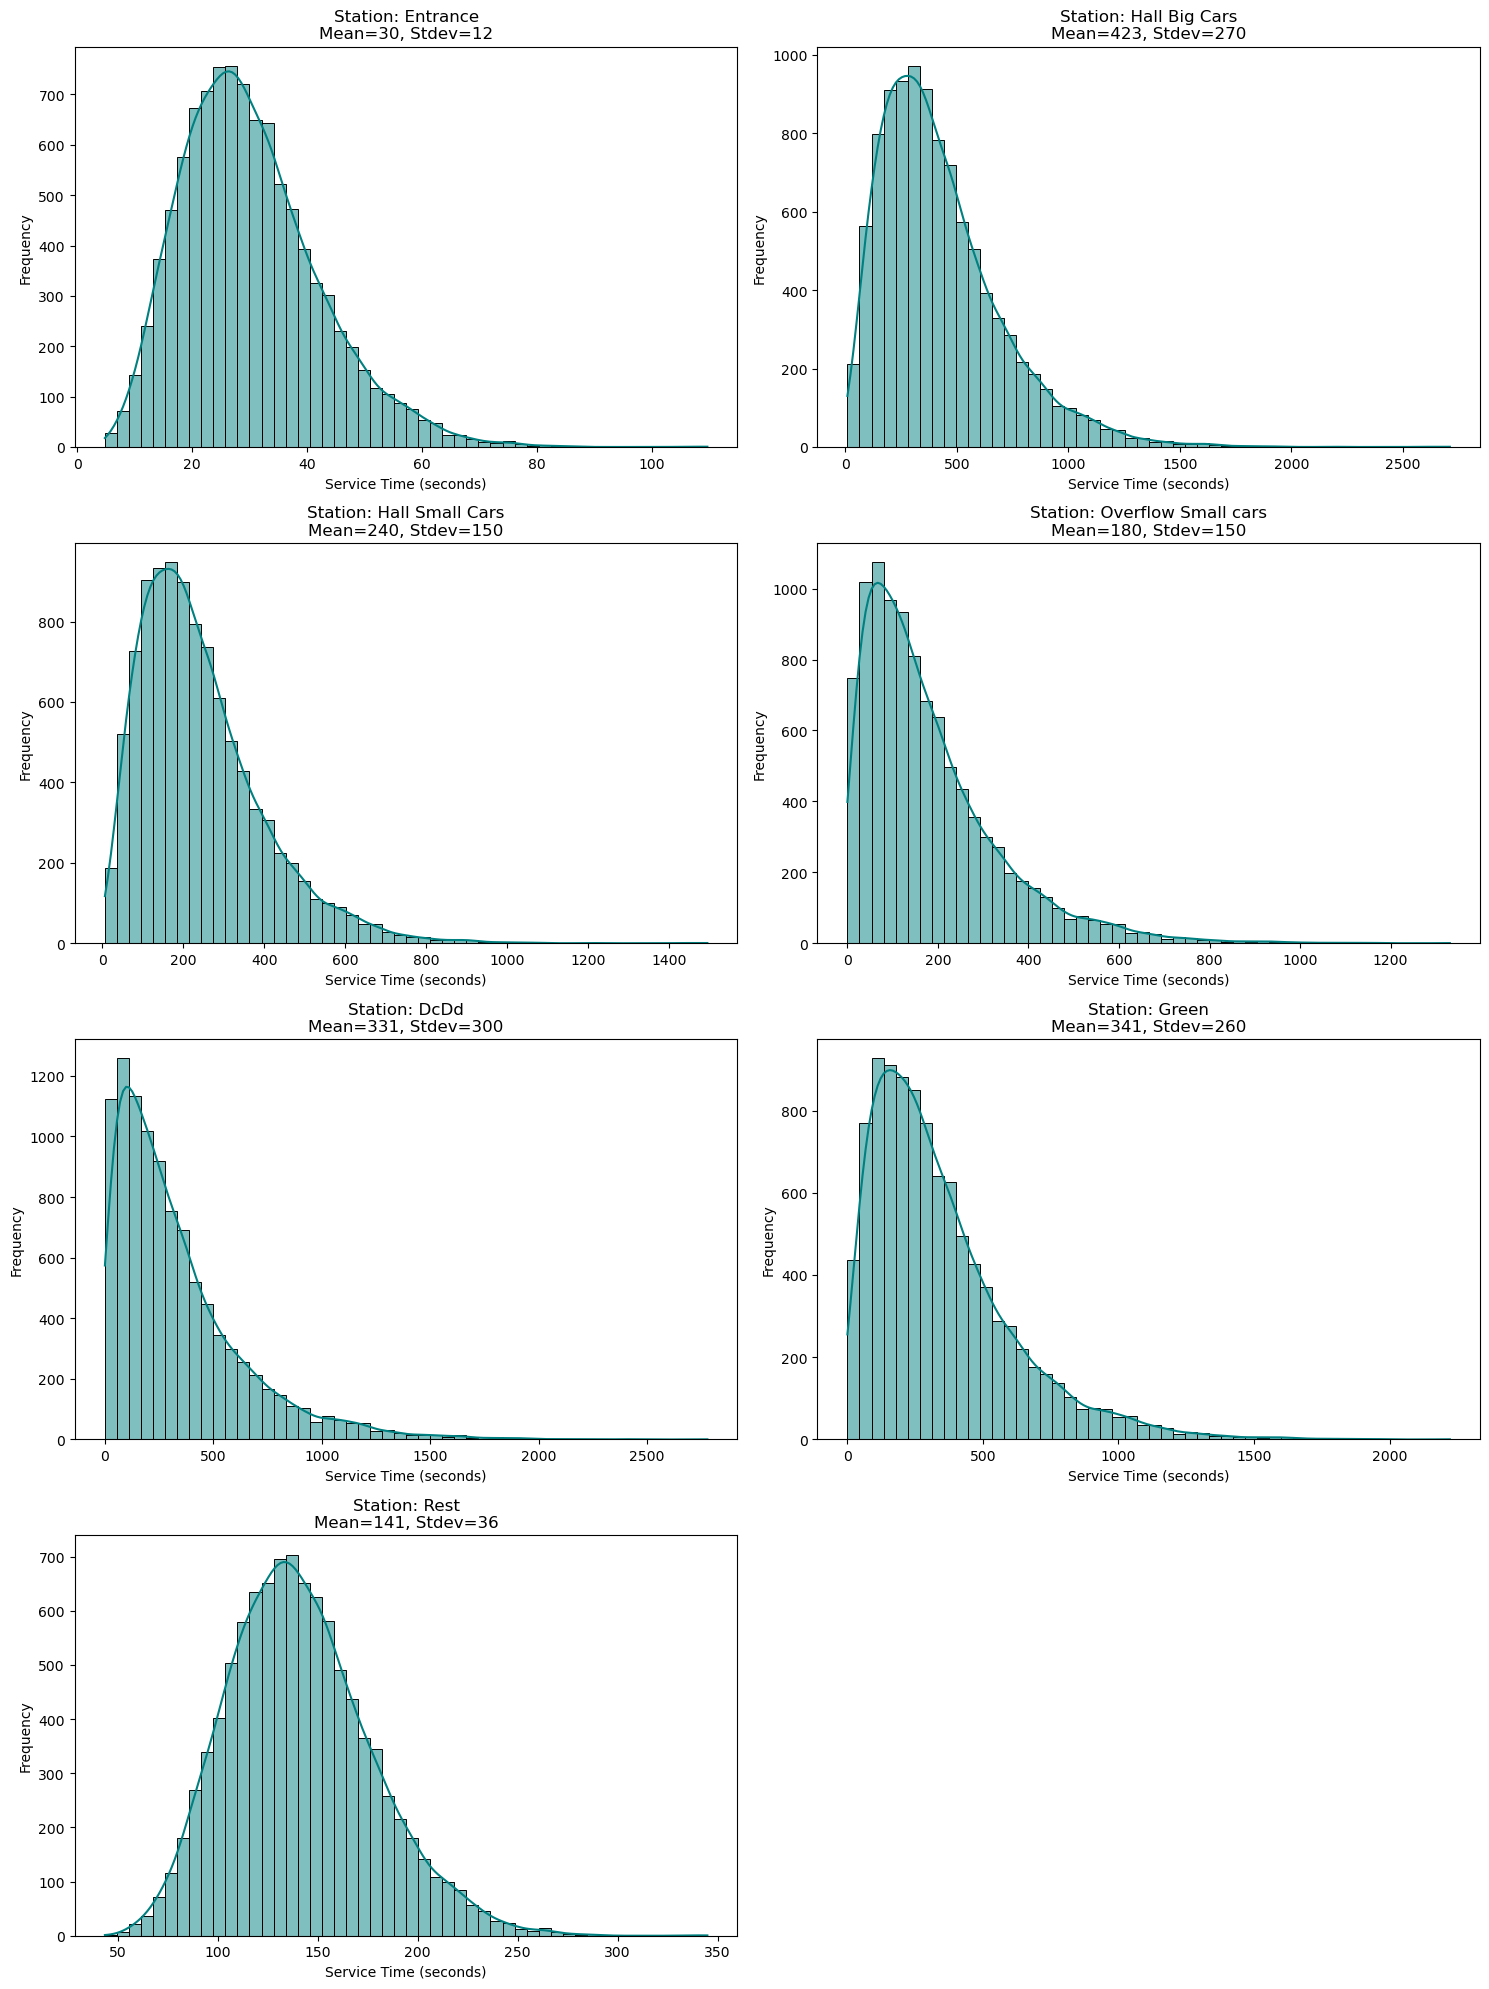

In [10]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

class Sampler:
    def __init__(self, name, params, seed=None):
        self.rng = np.random.default_rng(seed)
        if not hasattr(self.rng, name):
            raise AttributeError(f"NumPy Generator has no distribution: {name}")
        self._sampling_method = getattr(self.rng, name)
        self.dist_params = params

    def sample(self, size=None):
        # Squeeze arrays to scalars and force absolute values to prevent negative time steps
        val = self._sampling_method(**self.dist_params, size=size)
        return max(0.1, abs(float(np.squeeze(val))))

# Data extracted from the image's "Station names" table
stations_data = [
    {'name': 'Entrance', 'mean': 30, 'stdev': 12},
    {'name': 'Hall Big Cars', 'mean': 423, 'stdev': 270},
    {'name': 'Hall Small Cars', 'mean': 240, 'stdev': 150},
    {'name': 'Overflow Small cars', 'mean': 180, 'stdev': 150},
    {'name': 'DcDd', 'mean': 331, 'stdev': 300},
    {'name': 'Green', 'mean': 341, 'stdev': 260},
    {'name': 'Rest', 'mean': 141, 'stdev': 36}
]

# Set up our 4x2 grid of subplots for 7 stations
fig, axes = plt.subplots(4, 2, figsize=(15, 20))
axes = axes.flatten()

def get_gamma_params(mean, stdev):
    variance = stdev ** 2
    shape = (mean ** 2) / variance
    scale = variance / mean
    return {"shape": shape, "scale": scale}

# Example for 'Hall Big Cars' (Mean: 423, Stdev: 270)
params = get_gamma_params(423, 270)
sampler = Sampler("gamma", params) 
# Now sampler.sample() will accurately average 423 with a stdev of 270!

for i, data in enumerate(stations_data):
    # Map the mean and standard deviation to NumPy's gamma
    params = get_gamma_params(mean=data["mean"], stdev=data["stdev"])
    sampler = Sampler("gamma", params, seed=42)
    
    # Generate 10,000 samples for a smooth visualization. 
    # Because the provided class converts arrays to a single float, we use a loop to sample.
    samples = [sampler.sample() for _ in range(10000)]
    
    # Plot histogram and Kernel Density Estimate (KDE) curve
    sns.histplot(samples, kde=True, ax=axes[i], color='teal', bins=50)
    axes[i].set_title(f"Station: {data['name']}\nMean={data['mean']}, Stdev={data['stdev']}")
    axes[i].set_xlabel("Service Time (seconds)")
    axes[i].set_ylabel("Frequency")

# Hide the 8th empty subplot
axes[7].axis('off')

plt.tight_layout()
plt.savefig('service_time_distributions.png')